<a href="https://colab.research.google.com/github/zaebalreal/uni-projects/blob/main/progect_lol_dota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
with open("untitled.env", "w") as f:
    f.write("PANDASCORE_TOKEN=38r7nemgjvkV8DZuiLgf5mQg0ohE9ZP-y7JKR0sh5chYqn-jUck")

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv("untitled.env", override=True)

API_TOKEN = os.getenv("PANDASCORE_TOKEN")
print(API_TOKEN)

38r7nemgjvkV8DZuiLgf5mQg0ohE9ZP-y7JKR0sh5chYqn-jUck


In [ ]:
import os
import time
import logging
from datetime import datetime
from typing import Dict, Any, List

import requests
import pandas as pd
from dotenv import load_dotenv
from tqdm import tqdm


API_TOKEN = os.getenv("PANDASCORE_TOKEN")
BASE_URL = "https://api.pandascore.co"

if not API_TOKEN:
    raise ValueError("PANDASCORE_TOKEN not found. Put it inside .env file.")


logging.basicConfig(
    filename="scraping.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)


HEADERS = {
    "Authorization": f"Bearer {API_TOKEN}",
    "User-Agent": "SDS106-StudentProject/1.0"
}


def safe_get(url: str, params: Dict[str, Any], retries: int = 3) -> List[Dict[str, Any]]:
    """
    Sends a GET request with retries and basic rate-limit handling.
    """
    for attempt in range(retries):
        try:
            response = requests.get(url, headers=HEADERS, params=params, timeout=30)

            if response.status_code == 200:
                return response.json()

            logging.warning(f"Status {response.status_code} for {url}, params={params}")

            if response.status_code == 429:
                time.sleep(10)
            else:
                time.sleep(2)

        except requests.RequestException as e:
            logging.error(f"Request error: {e}")
            time.sleep(3)

    return []


def extract_match(match: Dict[str, Any], game_slug: str) -> Dict[str, Any]:
    """
    Extracts useful match-level fields from PandaScore match JSON.
    """
    opponents = match.get("opponents") or []

    team1 = None
    team2 = None

    if len(opponents) > 0:
        team1 = opponents[0].get("opponent", {}).get("name")
    if len(opponents) > 1:
        team2 = opponents[1].get("opponent", {}).get("name")

    results = match.get("results") or []
    team1_score = results[0].get("score") if len(results) > 0 else None
    team2_score = results[1].get("score") if len(results) > 1 else None

    videogame = match.get("videogame") or {}
    league = match.get("league") or {}
    tournament = match.get("tournament") or {}
    serie = match.get("serie") or {}
    winner = match.get("winner") or {}

    return {
        "match_id": match.get("id"),
        "game_slug": game_slug,
        "game_name": videogame.get("name"),
        "league_name": league.get("name"),
        "tournament_name": tournament.get("name"),
        "serie_name": serie.get("full_name") or serie.get("name"),
        "team1": team1,
        "team2": team2,
        "team1_score": team1_score,
        "team2_score": team2_score,
        "winner": winner.get("name"),
        "winner_id": match.get("winner_id"),
        "status": match.get("status"),
        "number_of_games": match.get("number_of_games"),
        "match_type": match.get("match_type"),
        "scheduled_at": match.get("scheduled_at"),
        "begin_at": match.get("begin_at"),
        "end_at": match.get("end_at"),
        "draw": match.get("draw"),
        "forfeit": match.get("forfeit"),
        "official_stream_url": match.get("official_stream_url")
    }


def scrape_game_matches(game_slug: str, max_pages: int = 60, per_page: int = 100) -> pd.DataFrame:
    """
    Scrapes historical matches for one game.
    Example endpoints:
    /lol/matches
    /dota2/matches
    """
    url = f"{BASE_URL}/{game_slug}/matches"
    rows = []

    for page in tqdm(range(1, max_pages + 1), desc=f"Scraping {game_slug}"):
        params = {
            "page[number]": page,
            "page[size]": per_page,
            "sort": "-begin_at"
        }

        data = safe_get(url, params=params)

        if not data:
            logging.info(f"No data for {game_slug}, page {page}")
            break

        for match in data:
            rows.append(extract_match(match, game_slug))

        time.sleep(1.2)

    return pd.DataFrame(rows)


def main():
    # csgo endpoint usually includes Counter-Strike / CS2 data in PandaScore naming.
    games = ["lol", "dota2"]

    all_dfs = []

    for game in games:
        df_game = scrape_game_matches(game_slug=game, max_pages=60, per_page=100)
        all_dfs.append(df_game)

    df = pd.concat(all_dfs, ignore_index=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    df.to_csv(f"raw_esports_matches_{timestamp}.csv", index=False)
    df.to_csv("raw_esports_matches.csv", index=False)

    print("Saved raw_esports_matches.csv")
    print("Shape:", df.shape)
    print(df.head())


if __name__ == "__main__":
    main()

Scraping dota2: 100%|██████████| 60/60 [04:46<00:00,  4.78s/it]


Saved raw_esports_matches.csv
Shape: (12000, 21)
   match_id game_slug game_name   league_name  tournament_name    serie_name  \
0   1397486       lol       LoL  EMEA Masters          Group G   Winter 2026   
1   1390926       lol       LoL  EMEA Masters  Champions Round   Winter 2026   
2   1384423       lol       LoL           LRN   Regular Season  Split 1 2026   
3   1384422       lol       LoL           LRN   Regular Season  Split 1 2026   
4   1355395       lol       LoL         LPLOL         Playoffs   Winter 2026   

              team1                          team2  team1_score  team2_score  \
0  WLGaming Esports  Unicorns Of Love Sexy Edition          0.0          0.0   
1      Movistar KOI                     FN Esports          0.0          0.0   
2      Icon Esports                          Fuego          0.0          0.0   
3      Icon Esports                   LYON Academy          0.0          0.0   
4    The Otter Side                 Vantex Esports          0.0       

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("raw_esports_matches.csv")

print("Before:", df.shape)

df = df.drop_duplicates(subset=["match_id", "game_slug"])

for col in ["scheduled_at", "begin_at", "end_at"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

for col in ["team1_score", "team2_score", "number_of_games"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# оставляем finished И partially available
df = df[df["status"] == "finished"]

# убираем только явный мусор
df = df[df["forfeit"] != True]

# убираем только критично пустые
df = df.dropna(subset=["team1", "team2"])

# winner можно оставить с NaN (для анализа)

df["total_score"] = df["team1_score"].fillna(0) + df["team2_score"].fillna(0)
df["score_diff"] = (df["team1_score"] - df["team2_score"]).abs()
df["has_winner"] = df["winner"].notna().astype(int)
df["is_bo3_or_more"] = (df["number_of_games"] >= 3).astype(int)

df["match_duration_minutes"] = (df["end_at"] - df["begin_at"]).dt.total_seconds() / 60
df.loc[df["match_duration_minutes"] < 0, "match_duration_minutes"] = np.nan

df["year"] = df["begin_at"].dt.year
df["month"] = df["begin_at"].dt.month
df["weekday"] = df["begin_at"].dt.day_name()

df["winner_side"] = np.where(
    df["winner"] == df["team1"], "team1",
    np.where(df["winner"] == df["team2"], "team2", "unknown")
)

df["match_duration_category"] = pd.cut(
    df["match_duration_minutes"],
    bins=[0, 45, 90, 180, 10000],
    labels=["short", "medium", "long", "very_long"]
)

df.to_csv("clean_esports_matches.csv", index=False)

print("After:", df.shape)
print(df.head())
print(df.isna().sum())

Before: (12000, 21)
After: (8978, 31)
    match_id game_slug game_name                         league_name  \
72   1137716       lol       LoL                        Asia Masters   
87   1037759       lol       LoL  Asia Star Challengers Invitational   
88   1037758       lol       LoL  Asia Star Challengers Invitational   
89   1037751       lol       LoL  Asia Star Challengers Invitational   
90   1037740       lol       LoL  Asia Star Challengers Invitational   

   tournament_name serie_name                         team1  \
72   Swiss Stage 1       2025       Weibo Gaming Youth Team   
87         Group A       2024         Dplus KIA Challengers   
88         Group A       2024    CTBC Flying Oyster Academy   
89         Group B       2024  Kwangdong Freecs Challengers   
90         Group C       2024        KT Rolster Challengers   

                     team2  team1_score  team2_score  ... total_score  \
72    Spirit Quartz Gaming          1.0          0.0  ...         1.0   
87  

In [ ]:
print(df.shape)
print(df["status"].value_counts())
print(df["game_slug"].value_counts())


(8978, 31)
status
finished    8978
Name: count, dtype: int64
game_slug
lol      5177
dota2    3801
Name: count, dtype: int64


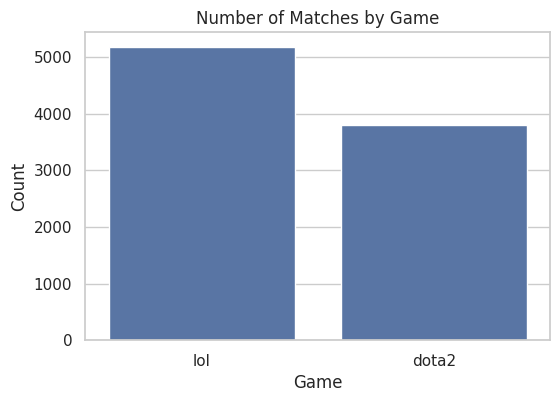

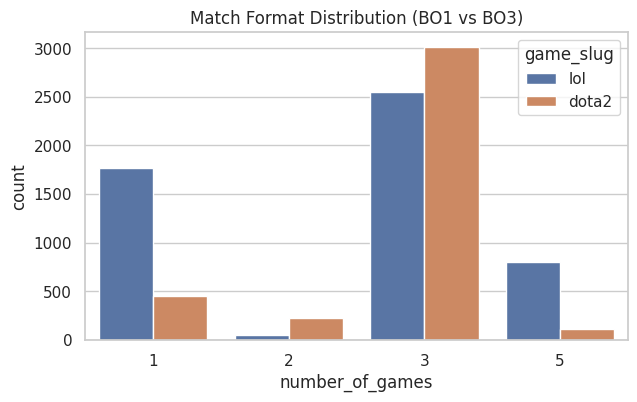

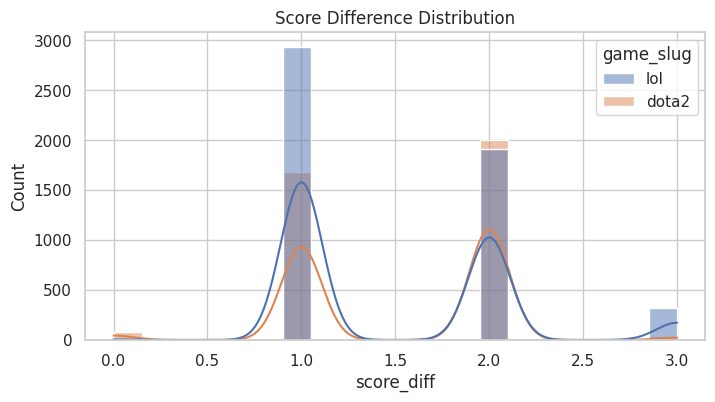

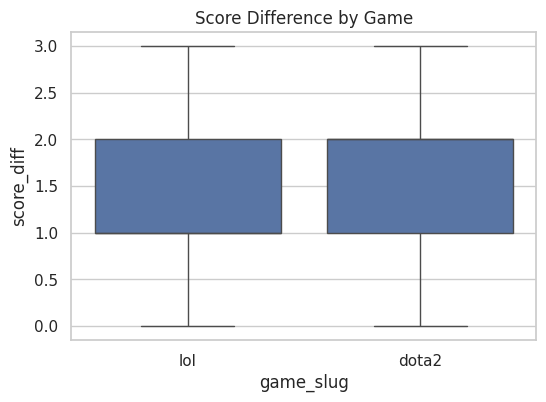

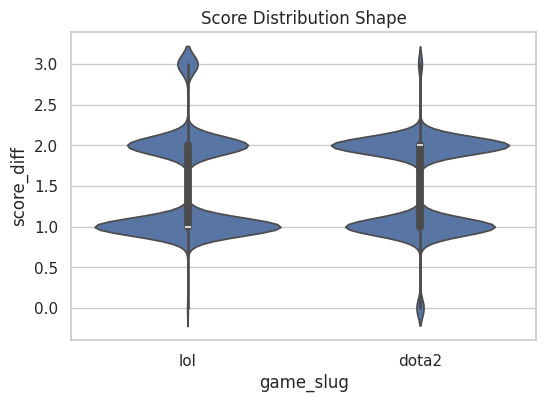

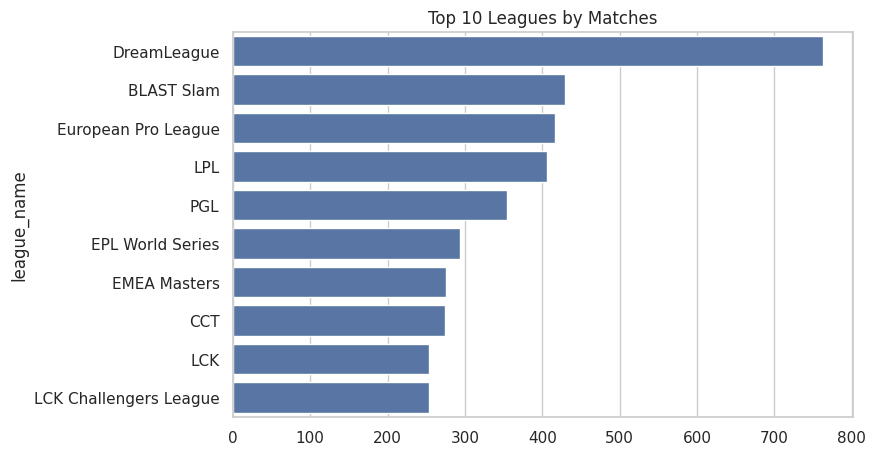

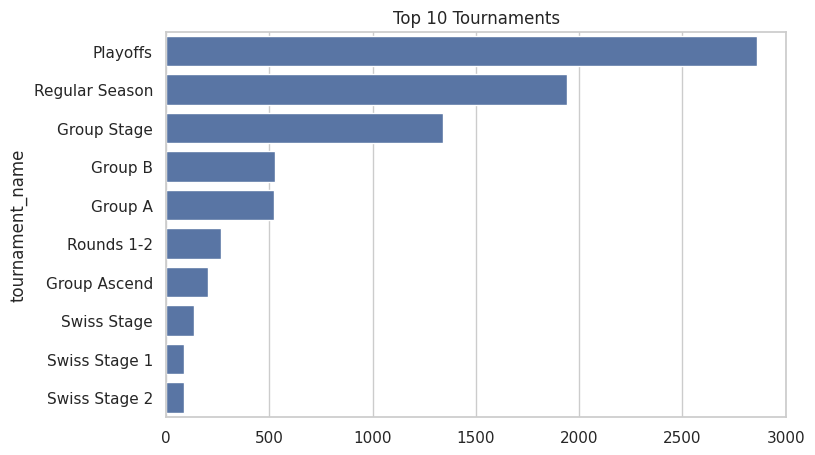

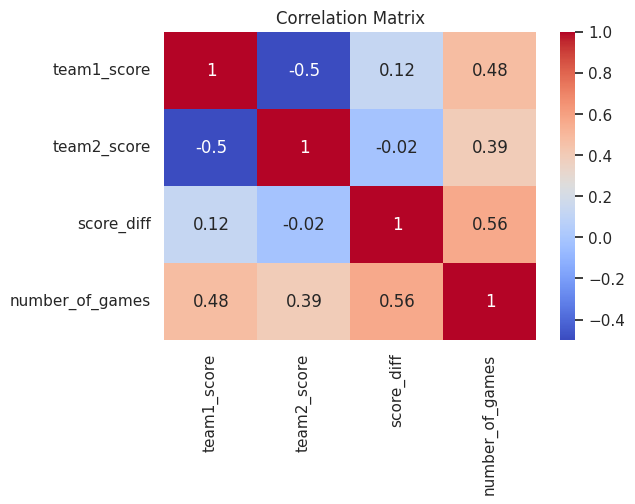

/tmp/ipykernel_1372/3574931383.py:76: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_time["month_period"] = df_time["begin_at"].dt.to_period("M").astype(str)


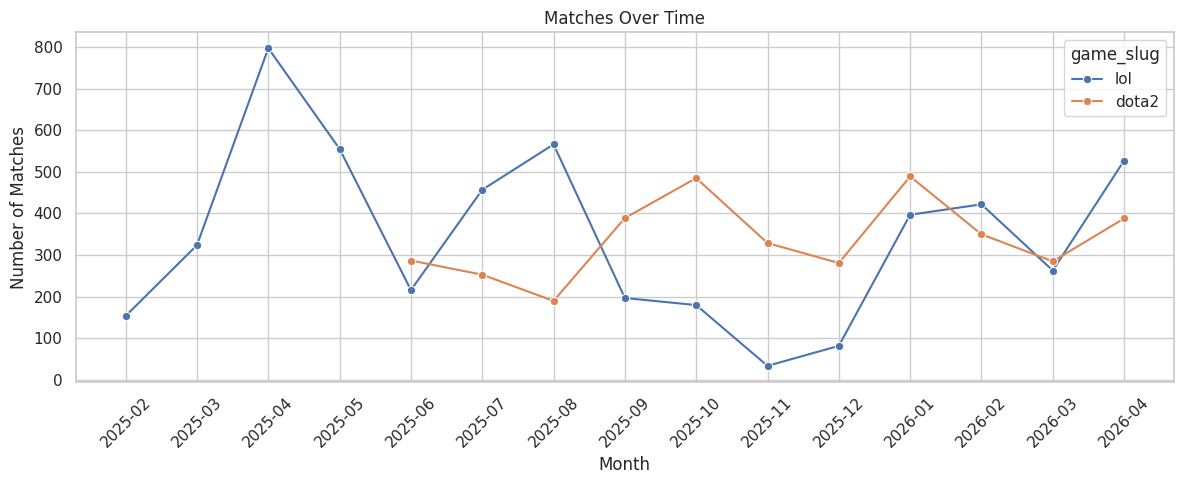

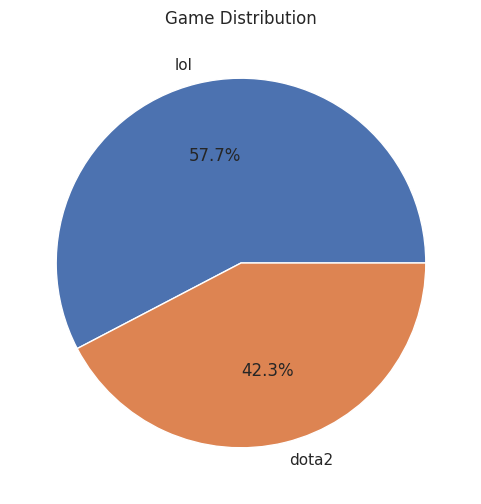

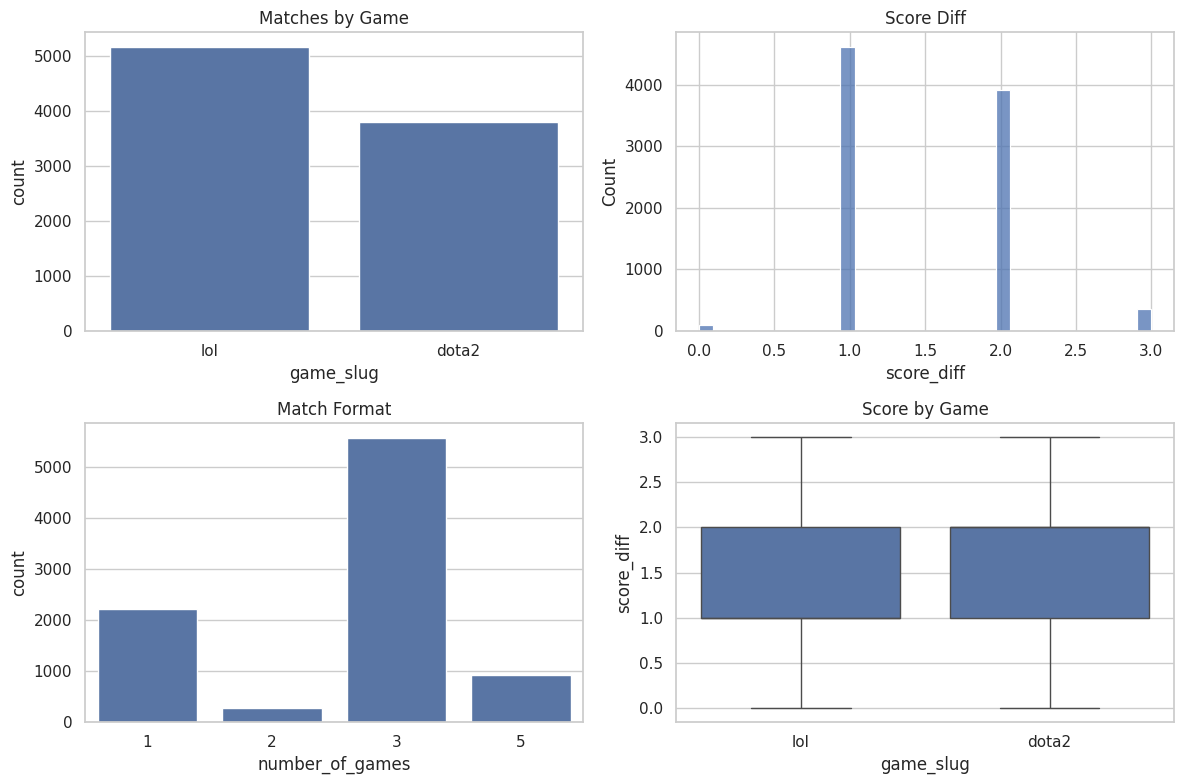

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set(style="whitegrid")

# 1. Matches by game
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="game_slug")
plt.title("Number of Matches by Game")
plt.xlabel("Game")
plt.ylabel("Count")
plt.show()

# 2. Match format
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="number_of_games", hue="game_slug")
plt.title("Match Format Distribution (BO1 vs BO3)")
plt.show()

# 3. Score difference histogram
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="score_diff", hue="game_slug", bins=20, kde=True)
plt.title("Score Difference Distribution")
plt.show()

# 4. Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="game_slug", y="score_diff")
plt.title("Score Difference by Game")
plt.show()

# 5. Violin plot
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x="game_slug", y="score_diff")
plt.title("Score Distribution Shape")
plt.show()

# 6. Top leagues
top_leagues = df["league_name"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(y=top_leagues.index, x=top_leagues.values)
plt.title("Top 10 Leagues by Matches")
plt.show()

# 7. Top tournaments
top_tournaments = df["tournament_name"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(y=top_tournaments.index, x=top_tournaments.values)
plt.title("Top 10 Tournaments")
plt.show()

# 8. Correlation heatmap
numeric_cols = ["team1_score","team2_score","score_diff","number_of_games"]

plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 9. Matches over time
# 9. Matches over time — fixed version

df_time = df.dropna(subset=["begin_at"]).copy()

df_time["begin_at"] = pd.to_datetime(
    df_time["begin_at"],
    errors="coerce",
    utc=True
)

df_time = df_time.dropna(subset=["begin_at"])

df_time["month_period"] = df_time["begin_at"].dt.to_period("M").astype(str)

time_series = (
    df_time
    .groupby(["month_period", "game_slug"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=time_series,
    x="month_period",
    y="count",
    hue="game_slug",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Matches Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# 10. Pie chart
game_counts = df["game_slug"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(game_counts, labels=game_counts.index, autopct="%1.1f%%")
plt.title("Game Distribution")
plt.show()

# 11. Plotly interactive scatter
fig = px.scatter(df,
                 x="number_of_games",
                 y="score_diff",
                 color="game_slug",
                 title="Match Format vs Score Difference",
                 template="plotly_white")
fig.show()

# 12. Plotly interactive bar

fig = px.bar(
    top_leagues,
    x=top_leagues.values,
    y=top_leagues.index,
    orientation="h",
    title="Top Leagues Interactive",
    template="plotly_white",
    color=top_leagues.values,
    color_continuous_scale="Blues"
)

fig.update_layout(
    xaxis_title="Number of Matches",
    yaxis_title="League",
    coloraxis_showscale=False
)

fig.show()

# 13. Dashboard (обязательный)
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.countplot(data=df, x="game_slug", ax=axes[0,0])
axes[0,0].set_title("Matches by Game")

sns.histplot(data=df, x="score_diff", ax=axes[0,1])
axes[0,1].set_title("Score Diff")

sns.countplot(data=df, x="number_of_games", ax=axes[1,0])
axes[1,0].set_title("Match Format")

sns.boxplot(data=df, x="game_slug", y="score_diff", ax=axes[1,1])
axes[1,1].set_title("Score by Game")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

ml_df = df.copy()

ml_df = ml_df.dropna(subset=[
    "game_slug",
    "league_name",
    "number_of_games",
    "team1_score",
    "team2_score",
    "score_diff",
    "winner_side"
])

ml_df = ml_df[ml_df["winner_side"].isin(["team1", "team2"])]

X = ml_df[[
    "game_slug",
    "league_name",
    "number_of_games",
    "team1_score",
    "team2_score",
    "score_diff"
]]

X = pd.get_dummies(X, columns=["game_slug", "league_name"], drop_first=True)

y = ml_df["winner_side"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       960
           1       1.00      1.00      1.00       818

    accuracy                           1.00      1778
   macro avg       1.00      1.00      1.00      1778
weighted avg       1.00      1.00      1.00      1778



Important note: this model is not a real pre-match prediction model because it uses post-match score features. It is included as a bonus task to demonstrate the machine learning classification workflow on esports match data.

A Random Forest classification model was implemented as a bonus task. The goal was to classify the winning side of a match using match-level features such as game, league, match format, score difference, and team scores. This model demonstrates how machine learning can be applied to esports match data.

Here is the real AI-module for our project:
https://colab.research.google.com/drive/1M4DlKGBBNGty3KoSGaIy0BGyRcOuNvAV?usp=sharing

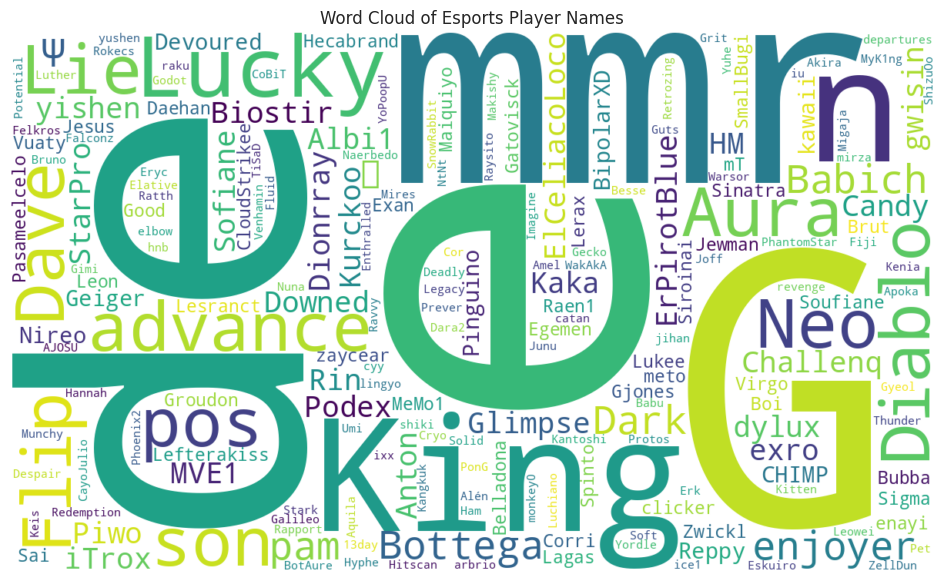

In [ ]:
import requests
import pandas as pd
import time
import os
from dotenv import load_dotenv

load_dotenv("untitled.env", override=True)

API_TOKEN = os.getenv("PANDASCORE_TOKEN")

headers = {
    "Authorization": f"Bearer {API_TOKEN}",
    "User-Agent": "SDS106-StudentProject/1.0"
}

def scrape_players(game_slug, pages=5, per_page=100):
    all_players = []

    for page in range(1, pages + 1):
        url = f"https://api.pandascore.co/{game_slug}/players"
        params = {
            "page[number]": page,
            "page[size]": per_page
        }

        response = requests.get(url, headers=headers, params=params)

        if response.status_code != 200:
            print(game_slug, page, response.status_code)
            break

        data = response.json()

        if not data:
            break

        for player in data:
            all_players.append({
                "game_slug": game_slug,
                "player_id": player.get("id"),
                "name": player.get("name"),
                "first_name": player.get("first_name"),
                "last_name": player.get("last_name"),
                "role": player.get("role"),
                "nationality": player.get("nationality")
            })

        time.sleep(1)

    return pd.DataFrame(all_players)


players_lol = scrape_players("lol", pages=5)
players_dota = scrape_players("dota2", pages=5)

players_df = pd.concat([players_lol, players_dota], ignore_index=True)

players_df = players_df.dropna(subset=["name"])
players_df.to_csv("players_data.csv", index=False)

players_df.head()

from wordcloud import WordCloud
import matplotlib.pyplot as plt

player_text = " ".join(players_df["name"].dropna().astype(str).tolist())

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis"
).generate(player_text)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Esports Player Names")
plt.show()



Text analysis was performed using league, tournament, and series names. A word cloud was created to identify the most common terms in the esports competition structure

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 56.4 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Esports Match Dashboard",
    layout="wide"
)

st.title("Esports Match Dashboard")
st.write(
    "Interactive dashboard for comparing Dota 2 and League of Legends matches "
    "collected from the PandaScore API."
)

df = pd.read_csv("clean_esports_matches.csv")

# Sidebar filters
st.sidebar.header("Filters")

games = st.sidebar.multiselect(
    "Select Game",
    options=sorted(df["game_slug"].unique()),
    default=sorted(df["game_slug"].unique())
)

df_filtered = df[
    (df["game_slug"].isin(games)) &
    (df["status"] == "finished")
]

# Key metrics
st.subheader("Key Metrics")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Matches", len(df_filtered))
col2.metric("Unique Leagues", df_filtered["league_name"].nunique())
col3.metric("Unique Tournaments", df_filtered["tournament_name"].nunique())
col4.metric("Average Score Difference", round(df_filtered["score_diff"].mean(), 2))

# Dataset preview
st.subheader("Dataset Preview")
st.dataframe(df_filtered.reset_index(drop=True).head(100))

# Chart 1
st.subheader("Matches by Game")

fig1 = px.histogram(
    df_filtered,
    x="game_slug",
    color="game_slug",
    title="Number of Matches by Game"
)

st.plotly_chart(fig1, use_container_width=True)

# Chart 2
st.subheader("Match Format Distribution")

fig2 = px.histogram(
    df_filtered,
    x="number_of_games",
    color="game_slug",
    barmode="group",
    title="Match Format Distribution"
)

st.plotly_chart(fig2, use_container_width=True)

# Chart 3
st.subheader("Score Difference by Game")

fig3 = px.box(
    df_filtered,
    x="game_slug",
    y="score_diff",
    color="game_slug",
    title="Score Difference by Game"
)

st.plotly_chart(fig3, use_container_width=True)

# Chart 4
st.subheader("Top 10 Leagues")

top_leagues = (
    df_filtered["league_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_leagues.columns = ["league_name", "matches"]

fig4 = px.bar(
    top_leagues,
    x="matches",
    y="league_name",
    orientation="h",
    title="Top 10 Leagues by Number of Matches"
)

st.plotly_chart(fig4, use_container_width=True)

# Short explanation
st.subheader("Dashboard Summary")

st.write(
    "This dashboard allows interactive exploration of esports match data. "
    "Users can filter by game and compare match volume, match format, score differences, "
    "and league activity. This supports the project by turning static analysis into an "
    "interactive analytical tool."
)


2026-04-28 09:48:28.027 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 09:48:28.028 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 09:48:28.282 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-28 09:48:28.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 09:48:28.283 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 09:48:28.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-28 09:48:28.286 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

As a bonus task, an interactive Streamlit dashboard was developed. It allows users to filter matches by game and explore key metrics such as total matches, unique leagues, unique tournaments, average score difference, match format distribution, and top leagues. This improves the project by turning static analysis into an interactive analytical tool.


http://localhost:8501

In [ ]:
comparison = df.groupby("game_slug").agg(
    total_matches=("match_id", "count"),
    unique_leagues=("league_name", "nunique"),
    unique_tournaments=("tournament_name", "nunique"),
    avg_score_diff=("score_diff", "mean"),
    median_score_diff=("score_diff", "median"),
    bo3_rate=("is_bo3_or_more", "mean")
).reset_index()

comparison["bo3_rate"] = comparison["bo3_rate"] * 100

comparison


,game_slug,total_matches,unique_leagues,unique_tournaments,avg_score_diff,median_score_diff,bo3_rate
0,dota2,3801,28,18,1.526967,2.0,82.241515
1,lol,5177,53,71,1.490632,1.0,64.805872


In [ ]:
import plotly.express as px

fig = px.bar(
    comparison,
    x="game_slug",
    y="total_matches",
    color="game_slug",
    title="Total Matches Comparison",
    template="plotly_white",
    color_discrete_sequence=["#1f77b4", "#ff7f0e"]
)

fig.show()

In [ ]:
fig2 = px.bar(
    comparison,
    x="game_slug",
    y="bo3_rate",
    color="game_slug",
    title="BO3 Match Percentage",
    template="plotly_white",
    color_discrete_sequence=["#1f77b4", "#ff7f0e"]
)

fig2.update_layout(
    yaxis_title="BO3 Matches (%)",
    xaxis_title="Game"
)

fig2.show()

In [ ]:
fig3 = px.bar(
    comparison,
    x="game_slug",
    y="avg_score_diff",
    color="game_slug",
    title="Average Score Difference",
    template="plotly_white",
    color_discrete_sequence=["#1f77b4", "#ff7f0e"]
)

fig3.update_layout(
    yaxis_title="Average Score Difference",
    xaxis_title="Game"
)

fig3.show()

Overall, this project analyzed more than 9,000 esports match records collected from the PandaScore API. The analysis focused on Dota 2 and League of Legends as two major esports disciplines. After cleaning and feature engineering, the dataset was used to explore match distribution, match formats, score differences, league activity, and tournament structure.

The results show that League of Legends has a larger number of recorded matches and more diverse league and tournament representation, while Dota 2 has a higher BO3 rate and slightly higher average score difference. This suggests that the two games have different competitive structures.

The project demonstrates a full data analysis pipeline: API-based data collection, cleaning, feature engineering, exploratory data analysis, visualization, machine learning, text analysis, and interactive dashboard development.

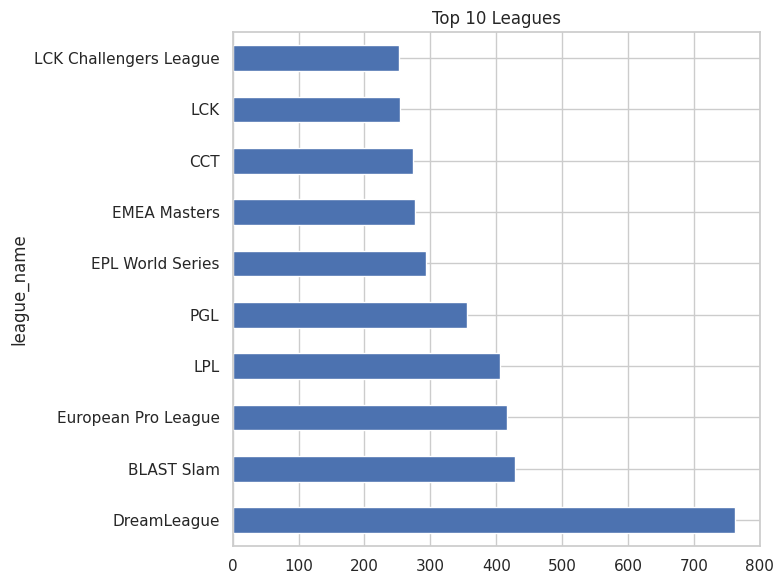

In [ ]:
import matplotlib.pyplot as plt

# 4. Top Leagues
top_leagues = df["league_name"].value_counts().head(10)


plt.figure(figsize=(8,6))
top_leagues.plot(kind="barh")
plt.title("Top 10 Leagues")
plt.tight_layout()  # ВАЖНО
plt.savefig("fig5_top_leagues.png")